Section 1: Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


Section 2: Business KPIs

Total Customers

In [2]:
total_customers = len(df)
total_customers

7043

Churned Customers

In [3]:
churned_customers = df["Churn_Flag"].sum()
churned_customers

np.int64(1869)

Churn Rate

In [4]:
churn_rate = (
    churned_customers /
    total_customers
) * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.54%


Revenue at Risk

In [5]:
revenue_at_risk = (
    df[df["Churn_Flag"] == 1]
    ["MonthlyCharges"]
    .sum()
)

print(f"${revenue_at_risk:,.2f}")

$139,130.85


Key KPI Summary

- Total Customers
- Churn Rate
- Revenue at Risk
- Average Monthly Revenue

Section 3: Churn Distribution

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Visualization

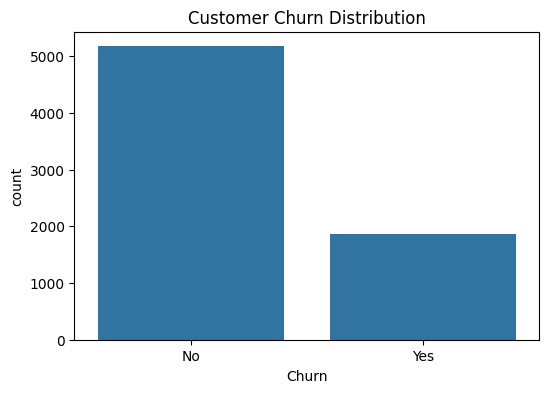

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")

plt.show()

The majority of customers are retained however, the churned customer base represents a significant revenue risk.

Section 4: Contract Analysis

In [8]:
contract_analysis = (
    df.groupby("Contract")
      ["Churn_Flag"]
      .mean()
      * 100
)

contract_analysis.sort_values(
    ascending=False
)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_Flag, dtype: float64

Visualization

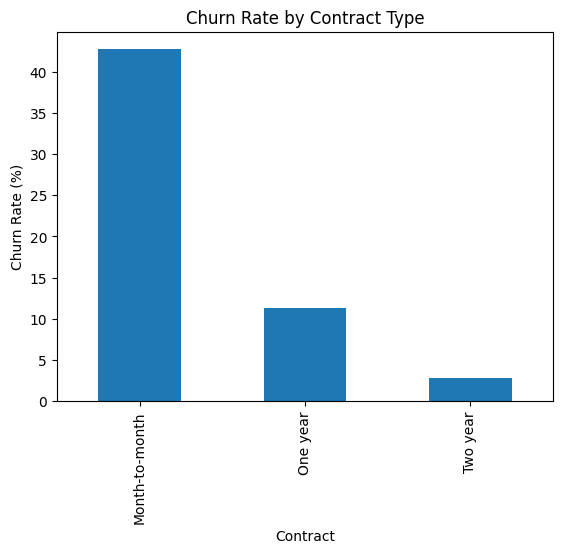

In [9]:
contract_analysis.sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Contract Type")

plt.show()

Month-to-month customers exhibit significantly higher churn rates than customers on one-year or two-year contracts.

Section 5: Payment Method Analysis

In [10]:
payment_analysis = (
    df.groupby("PaymentMethod")
      ["Churn_Flag"]
      .mean()
      * 100
)

payment_analysis.sort_values(
    ascending=False
)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn_Flag, dtype: float64

Visualization

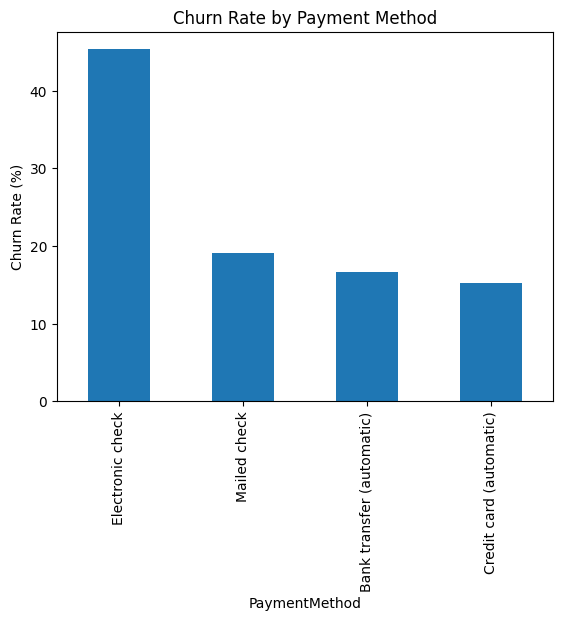

In [11]:
payment_analysis.sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Payment Method")

plt.show()

Section 6: Tenure Analysis

Create Tenure Buckets

In [12]:
df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

Analysis

In [13]:
tenure_analysis = (
    df.groupby("Tenure_Group")
      ["Churn_Flag"]
      .mean()
      * 100
)

tenure_analysis

Tenure_Group
0-12 Months     47.678161
13-24 Months    28.710938
25-48 Months    20.388959
49-72 Months     9.513176
Name: Churn_Flag, dtype: float64

Visualization

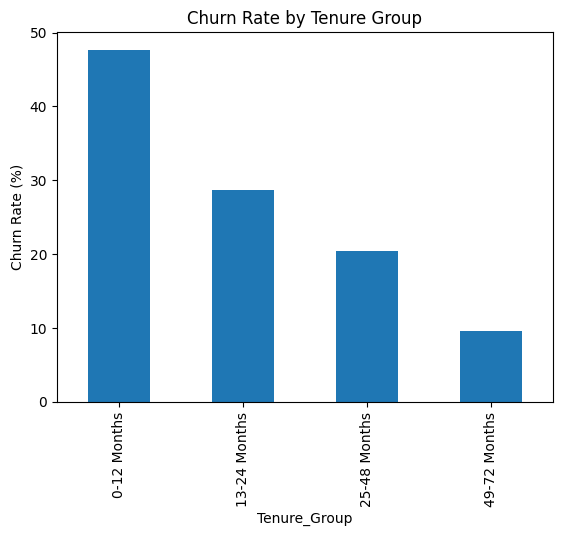

In [14]:
tenure_analysis.plot(
    kind="bar"
)

plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Tenure Group")

plt.show()

Newer customers churn substantially more often than long-tenured customers.

Section 7: Monthly Charges Analysis

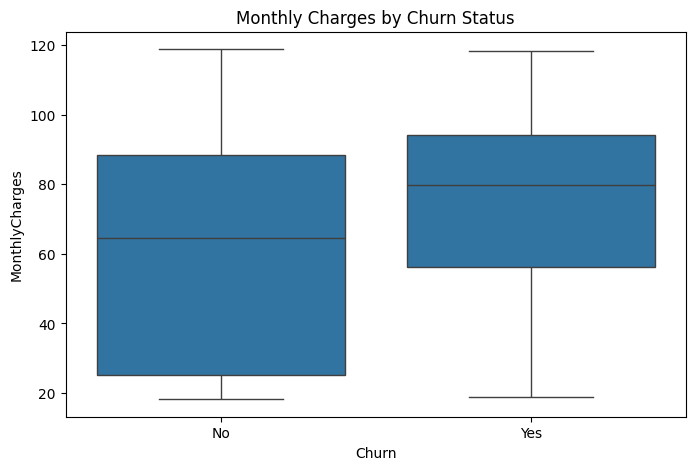

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title(
    "Monthly Charges by Churn Status"
)

plt.show()

Section 8: Internet Service Analysis

In [16]:
internet_analysis = (
    df.groupby("InternetService")
      ["Churn_Flag"]
      .mean()
      * 100
)

internet_analysis

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn_Flag, dtype: float64

Visualization

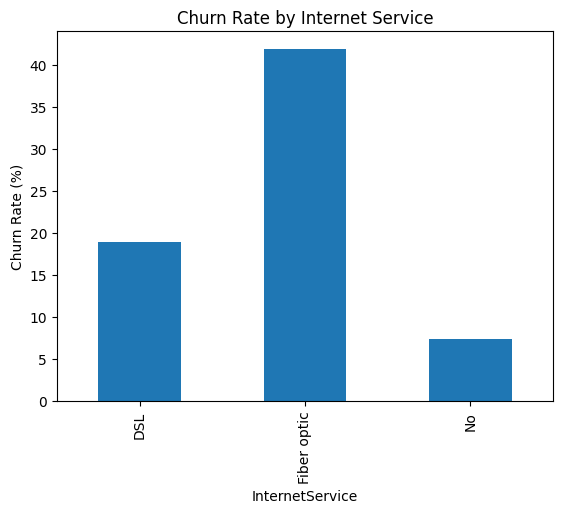

In [17]:
internet_analysis.plot(
    kind="bar"
)

plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Internet Service")

plt.show()

Key Findings

1. Overall churn rate is 26.54 %.

2. Month-to-month customers have the highest churn rate.

3. Customers with less than one year tenure are most likely to churn.

4. Certain payment methods show significantly higher churn.

5. Revenue at risk is approximately $139,131 per month.

Recommendations

- Encourage long-term contracts.
- Improve onboarding for new customers.
- Target high-risk customer segments with retention campaigns.